<a href="https://colab.research.google.com/github/ansmalik67/nanSense-ds-hack/blob/ramya_branch/challenge_submission_group_O_order_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
Data=pd.read_csv('/content/dataset_B_training.csv')

In [3]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

In [4]:
print(Data.head())

   respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0              1           1.0             2.0                        0.0   
1              2           1.0             1.0                        0.0   
2              3           2.0             1.0                        0.0   
3              4           0.0             1.0                        0.0   
4              5           2.0             0.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   1.0                   0.0                    1.0   
1                   0.0                   0.0                    0.0   
2                   1.0                   0.0                    1.0   
3                   1.0                   0.0                    1.0   
4                   0.0                   0.0                    0.0   

   behavioral_large_gatherings  behavioral_outside_home  \
0                          0.0               

In [5]:
Data.isnull().sum()

,0
respondent_id,0
h1n1_concern,15
h1n1_knowledge,22
behavioral_antiviral_meds,17
behavioral_avoidance,27
behavioral_face_mask,4
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,15
behavioral_touch_face,20


In [6]:
Data.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,4756.00000,4741.000000,4734.000000,4739.000000,4729.000000,4752.000000,4748.000000,4747.000000,4741.000000,4736.000000,...,4595.000000,4622.000000,4625.000000,2831.000000,4687.000000,4692.000000,4692.000000,4722.000000,4722.000000,4756.000000
mean,2378.50000,1.658933,1.307140,0.057396,0.740960,0.077652,0.842039,0.359385,0.341278,0.704814,...,0.314037,0.090437,0.141189,0.901801,3.965436,2.512361,2.412191,0.888818,0.542143,0.394029
std,1373.08327,0.892478,0.612811,0.232622,0.438154,0.267651,0.364743,0.479871,0.474189,0.456174,...,0.464182,0.286838,0.348254,0.297635,0.981737,1.336426,1.372509,0.755777,0.931243,0.488692
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,4.000000,1.000000,1.000000,1.000000
max,4756.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


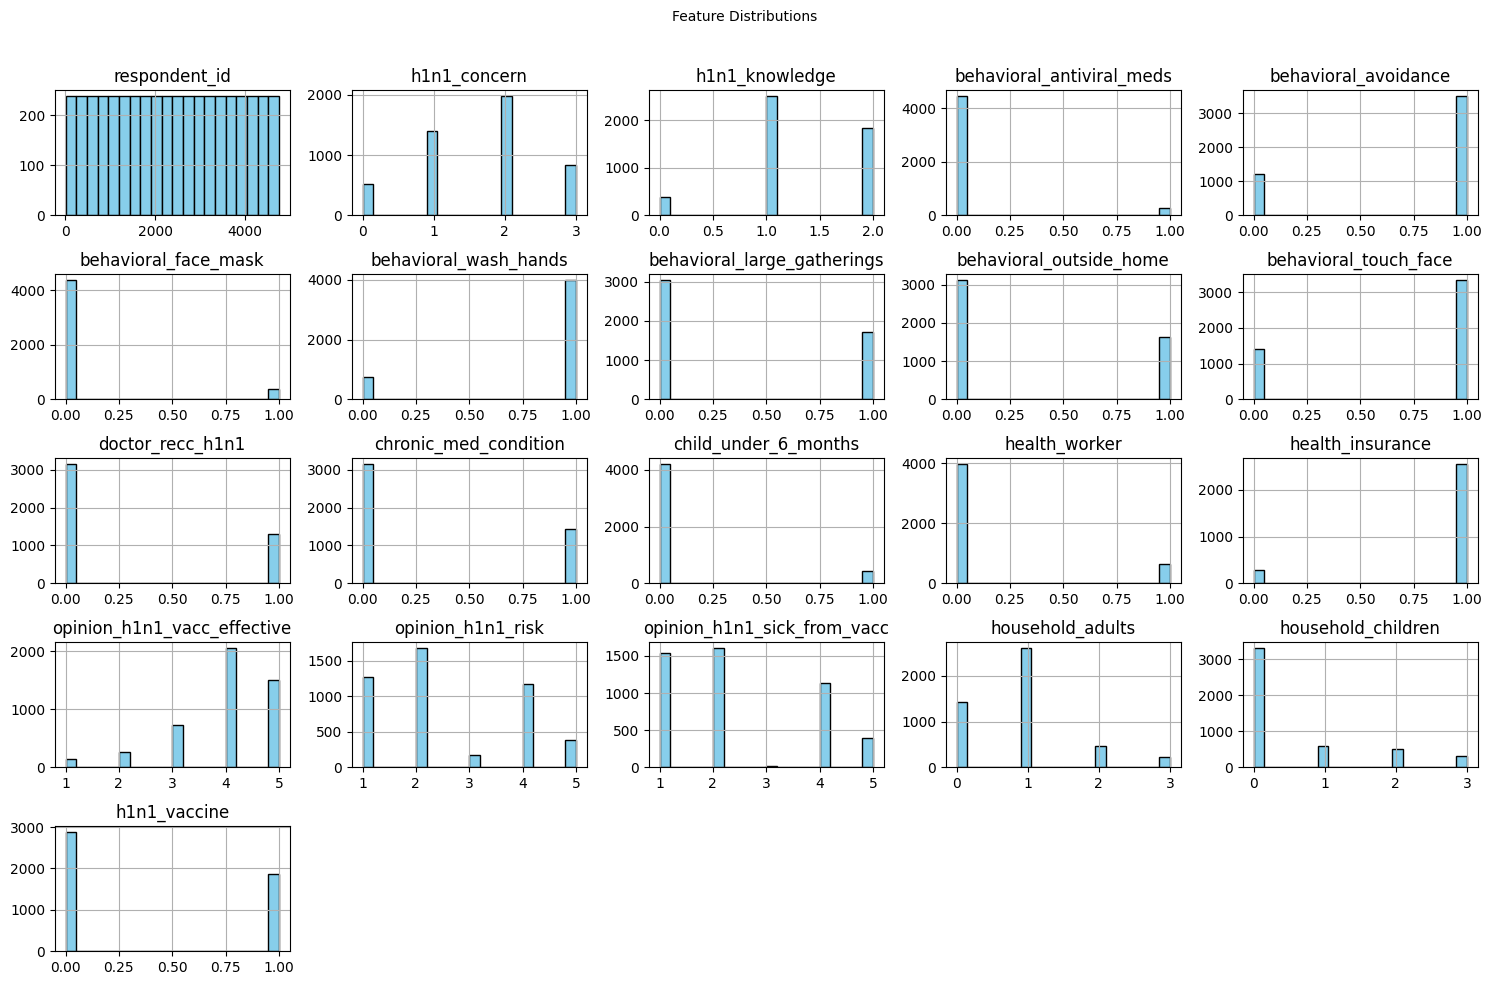

In [7]:
from matplotlib import pyplot as plt
Data.hist(figsize=(15,10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=10)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

[]

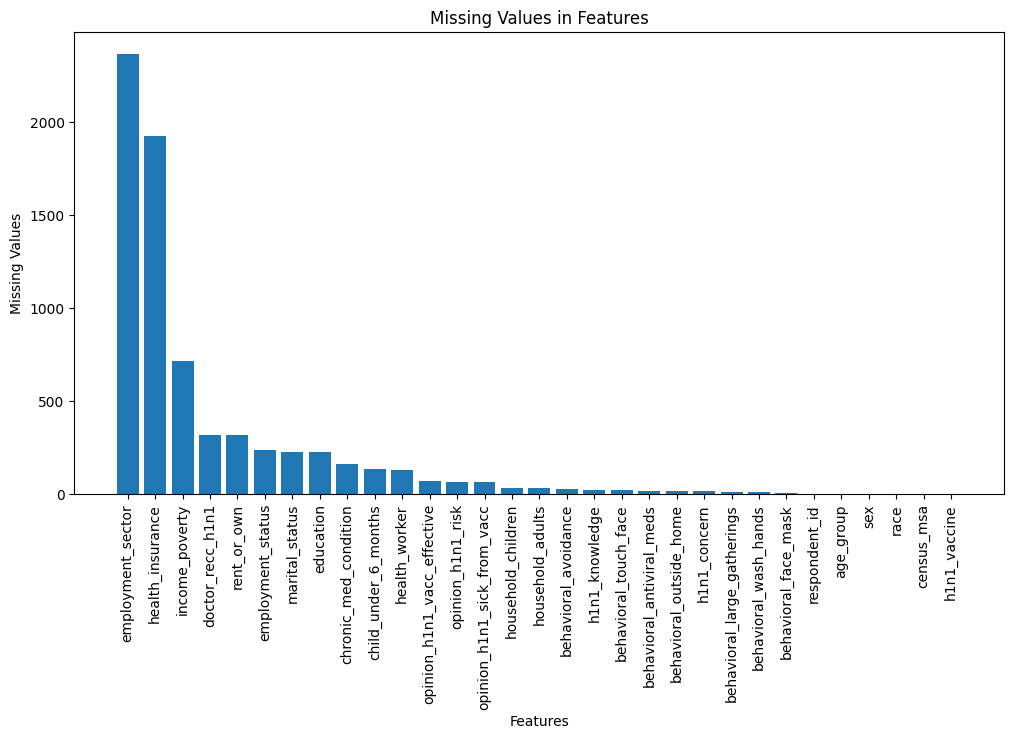

In [8]:
missing_value_plot=Data.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(missing_value_plot.index, missing_value_plot.values)
plt.xlabel('Features')
plt.ylabel('Missing Values')
plt.title('Missing Values in Features')
plt.xticks(rotation=90)
plt.plot()

In [9]:
numeric_cols = Data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = Data.select_dtypes(include=['object']).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'household_adults', 'household_children', 'h1n1_vaccine']
Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [10]:
print(Data.sex.value_counts())

sex
Female    2921
Male      1835
Name: count, dtype: int64


In [11]:
numeric_cols=  ['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
    'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face',
    'doctor_recc_h1n1', 'chronic_med_condition', 'health_worker', 'health_insurance',
    'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'household_adults', 'household_children', 'h1n1_vaccine']

In [12]:
Data['h1n1_concern']=Data['h1n1_concern'].fillna(2.0)

In [13]:
Data['h1n1_knowledge']=Data['h1n1_knowledge'].fillna(2.0)

In [14]:
Data['behavioral_antiviral_meds']=Data['behavioral_antiviral_meds'].fillna(Data['behavioral_antiviral_meds'].mode()[0])

In [15]:
Data['behavioral_avoidance']=Data['behavioral_avoidance'].fillna(Data['behavioral_avoidance'].mode()[0])

In [16]:
Data['behavioral_face_mask']=Data['behavioral_face_mask'].fillna(Data['behavioral_face_mask'].mode()[0])

In [17]:
Data['behavioral_wash_hands']=Data['behavioral_wash_hands'].fillna(Data['behavioral_wash_hands'].mode()[0])

In [18]:
Data['behavioral_large_gatherings']=Data['behavioral_large_gatherings'].fillna(Data['behavioral_large_gatherings'].mode()[0])

In [19]:
Data['behavioral_outside_home']=Data['behavioral_outside_home'].fillna(Data['behavioral_outside_home'].mode()[0])

In [20]:
Data['behavioral_touch_face']=Data['behavioral_touch_face'].fillna(Data['behavioral_touch_face'].mode()[0])

In [21]:
Data['doctor_recc_h1n1']=Data['doctor_recc_h1n1'].fillna(Data['doctor_recc_h1n1'].mode()[0])

In [22]:
Data['chronic_med_condition']=Data['chronic_med_condition'].fillna(Data['chronic_med_condition'].mode()[0])

In [23]:
Data['child_under_6_months']=Data['child_under_6_months'].fillna(Data['child_under_6_months'].mode()[0])

In [24]:
Data['health_insurance']=Data['health_insurance'].fillna(Data['health_insurance'].mode()[0])

In [25]:
Data['health_worker']=Data['health_worker'].fillna(Data['health_worker'].mode()[0])

In [26]:
Data['opinion_h1n1_sick_from_vacc']=Data['opinion_h1n1_sick_from_vacc'].fillna(2)

In [27]:
Data['opinion_h1n1_risk']=Data['opinion_h1n1_risk'].fillna(2)

In [28]:
Data['opinion_h1n1_vacc_effective']=Data['opinion_h1n1_vacc_effective'].fillna(4)

In [29]:
print(Data['education'])

0           Some College
1           Some College
2       College Graduate
3       College Graduate
4             < 12 Years
              ...       
4751        Some College
4752    College Graduate
4753          < 12 Years
4754    College Graduate
4755            12 Years
Name: education, Length: 4756, dtype: object


In [30]:
Data['education']=Data['education'].fillna(Data['education'].mode()[0])

In [31]:
Data['income_poverty']

,income_poverty
0,"<= $75,000, Above Poverty"
1,Below Poverty
2,"> $75,000"
3,"<= $75,000, Above Poverty"
4,NaN
...,...
4751,"> $75,000"
4752,"<= $75,000, Above Poverty"
4753,Below Poverty
4754,"> $75,000"


In [32]:
Data['income_poverty']=Data['income_poverty'].fillna(Data['income_poverty'].mode()[0])

In [33]:
Data['marital_status']=Data['marital_status'].fillna(Data['marital_status'].mode()[0])

In [34]:
Data['rent_or_own']=Data['rent_or_own'].fillna(Data['rent_or_own'].mode()[0])

In [35]:
Data['employment_status']=Data['employment_status'].fillna(Data['employment_status'].mode()[0])

In [36]:
Data['household_adults']=Data['household_adults'].fillna(1.0)

In [37]:
Data['household_children']=Data['household_children'].fillna(0.0)

In [38]:
Data['employment_sector']

,employment_sector
0,science
1,wholesale
2,education
3,NaN
4,NaN
...,...
4751,agriculture
4752,NaN
4753,NaN
4754,entertainment


In [39]:
Data['employment_sector']=Data['employment_sector'].fillna(Data['employment_sector'].mode()[0])

In [40]:
Data.isnull().sum()

,0
respondent_id,0
h1n1_concern,0
h1n1_knowledge,0
behavioral_antiviral_meds,0
behavioral_avoidance,0
behavioral_face_mask,0
behavioral_wash_hands,0
behavioral_large_gatherings,0
behavioral_outside_home,0
behavioral_touch_face,0


In [41]:
Data = pd.get_dummies(Data, drop_first=True)

In [42]:
X = Data.drop('h1n1_vaccine', axis=1)
y = Data['h1n1_vaccine']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [44]:
for col in X_train.columns:
    if any(char in str(col) for char in ['[',']','<','>']):
        print(col)

education_< 12 Years
income_poverty_> $75,000


In [45]:
import re
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train.columns = [re.sub(r'[<>()\[\]]', '_', str(col)) for col in X_train.columns]
X_test.columns = [re.sub(r'[<>()\[\]]', '_', str(col)) for col in X_test.columns]

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.764540995094604
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       850
           1       0.75      0.63      0.68       577

    accuracy                           0.76      1427
   macro avg       0.76      0.74      0.75      1427
weighted avg       0.76      0.76      0.76      1427



In [46]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Base model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Best model
best_xgb = random_search.best_estimator_

# Predictions
y_pred = best_xgb.predict(X_test)
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV Score:
0.7729047844837318

Test Accuracy:
0.759635599159075

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       850
           1       0.74      0.62      0.68       577

    accuracy                           0.76      1427
   macro avg       0.76      0.74      0.74      1427
weighted avg       0.76      0.76      0.76      1427



In [47]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.767344078486335
              precision    recall  f1-score   support

           0       0.77      0.86      0.82       850
           1       0.76      0.63      0.69       577

    accuracy                           0.77      1427
   macro avg       0.76      0.74      0.75      1427
weighted avg       0.77      0.77      0.76      1427



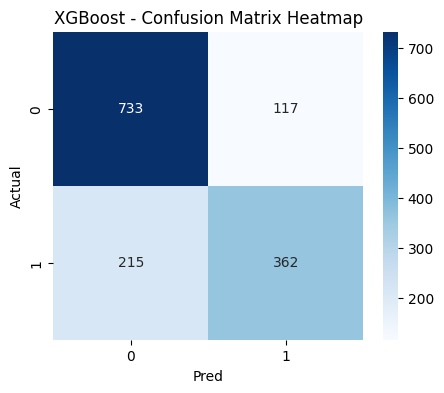

In [48]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost - Confusion Matrix Heatmap")
plt.xlabel("Pred")
plt.ylabel("Actual")
plt.show()

In [49]:
test_data = pd.read_csv("dataset_B_testing.csv")

respondent_id = test_data["respondent_id"]

X_test = test_data.drop(columns=["respondent_id"])

In [50]:
test_data.isnull().sum()

,0
respondent_id,0
h1n1_concern,21
h1n1_knowledge,18
behavioral_antiviral_meds,14
behavioral_avoidance,47
behavioral_face_mask,3
behavioral_wash_hands,6
behavioral_large_gatherings,27
behavioral_outside_home,12
behavioral_touch_face,30


In [51]:
for col in X_test.columns:
    if X_test[col].dtype == "object":
        X_test[col] = X_test[col].fillna(X_test[col].mode()[0])
    else:
        X_test[col] = X_test[col].fillna(X_test[col].median())

In [52]:
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

predictions = xgb.predict(X_test)

# Convert probabilities to binary if needed
predictions = [1 if p >= 0.5 else 0 for p in predictions]
submission = pd.DataFrame({
    "respondent_id": respondent_id,
    "h1n1_vaccine": predictions
})

# Save CSV
submission.to_csv("h1n1_predictions.csv", index=False)

print("Prediction file saved successfully!")
print(submission.head())

Prediction file saved successfully!
   respondent_id  h1n1_vaccine
0           4757             0
1           4758             0
2           4759             0
3           4760             0
4           4761             0


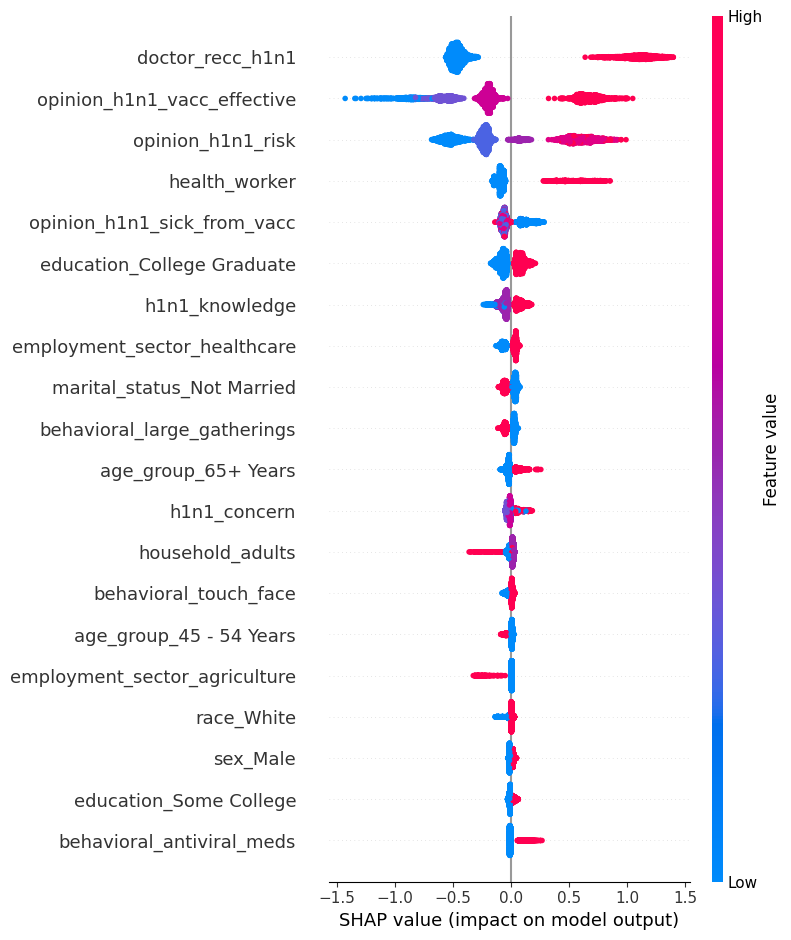

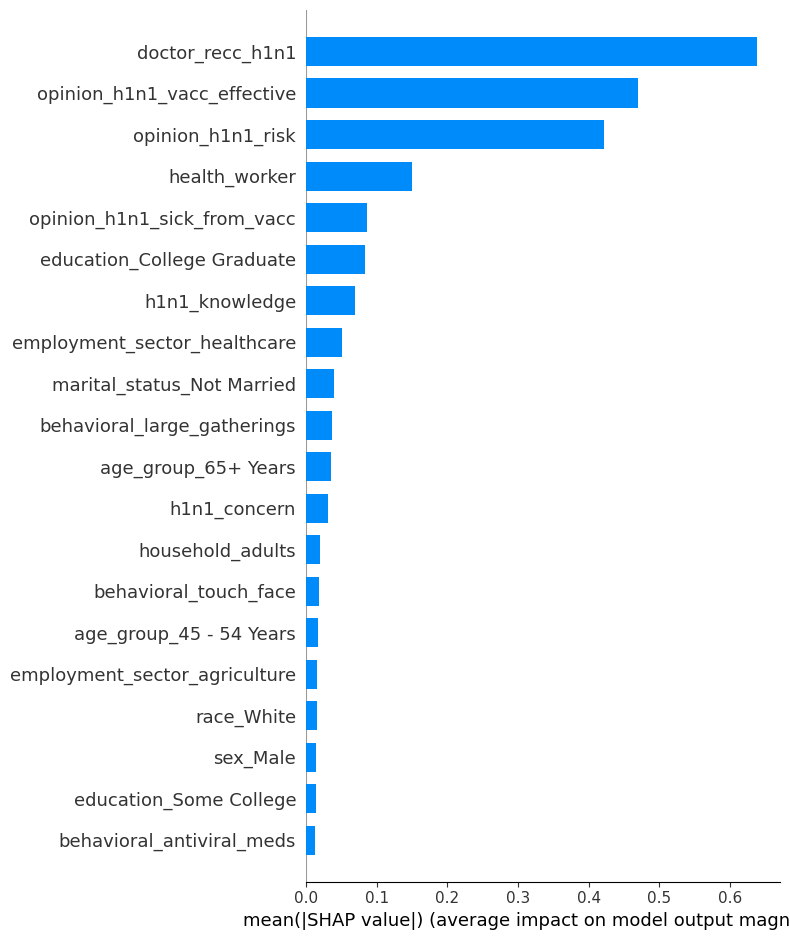

In [54]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot (Feature Importance)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test)

# Bar Plot of Feature Importance
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [55]:
# Explain first prediction
shap.initjs()

sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

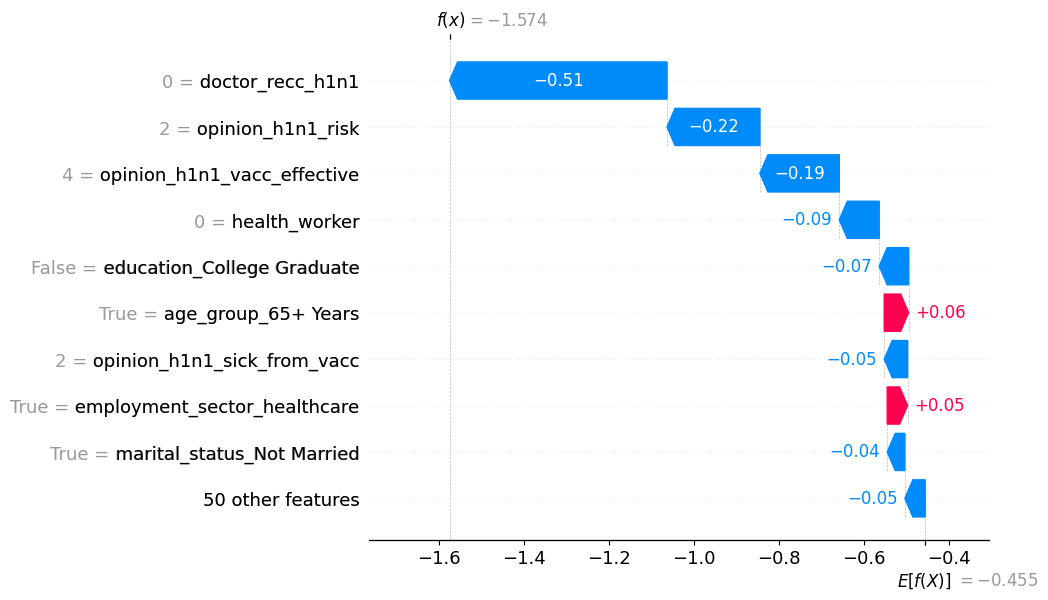

In [56]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)